[*] Meta-Analysis complete. Pooled AUC: 0.518
[*] Forest Plot saved to: loco_forest_plot.png


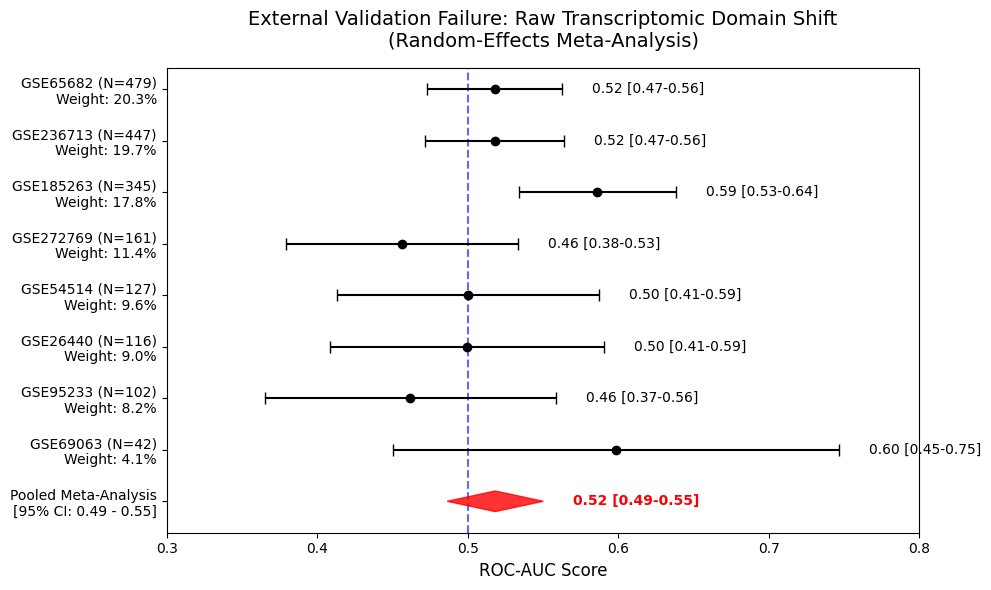

In [1]:
"""
CELL 1: Random-Effects Meta-Analysis & Forest Plot
Takes the raw LOCO validation AUCs, calculates their standard errors based on 
cohort sample sizes (N), and pools them using a Random-Effects model. 
Generates a publication-grade Forest Plot to visually demonstrate the failure 
of unharmonized cross-center transcriptomic prediction (The "Null Effect").
"""

import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Suppress warnings
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION
# ==========================================
BASE_DIR = Path("/workspace")
FIG_DIR = BASE_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The exact results from your harmonized LOCO run
loco_results = [
    {"Cohort": "GSE185263", "N": 345, "AUC": 0.5861},
    {"Cohort": "GSE26440",  "N": 116, "AUC": 0.4994},
    {"Cohort": "GSE54514",  "N": 127, "AUC": 0.5000},
    {"Cohort": "GSE65682",  "N": 479, "AUC": 0.5178},
    {"Cohort": "GSE95233",  "N": 102, "AUC": 0.4619},
    {"Cohort": "GSE236713", "N": 447, "AUC": 0.5178},
    {"Cohort": "GSE272769", "N": 161, "AUC": 0.4563},
    {"Cohort": "GSE69063",  "N": 42,  "AUC": 0.5984},
]

df = pd.DataFrame(loco_results)

# ==========================================
# META-ANALYSIS MATH (Standard Error & Weights)
# ==========================================
# Hanley & McNeil approximation for AUC Standard Error
# SE = sqrt((AUC * (1 - AUC)) / N) -> simplified approximation for variance
df['SE'] = np.sqrt((df['AUC'] * (1 - df['AUC'])) / df['N'])
df['Variance'] = df['SE'] ** 2

# Calculate Fixed-Effects Inverse Variance Weights
df['Weight_FE'] = 1 / df['Variance']

# Calculate Cochran's Q (Heterogeneity)
weighted_mean_FE = np.sum(df['Weight_FE'] * df['AUC']) / np.sum(df['Weight_FE'])
Q = np.sum(df['Weight_FE'] * (df['AUC'] - weighted_mean_FE)**2)
df_Q = len(df) - 1

# Calculate Tau-squared (Between-study variance) using DerSimonian-Laird
c = np.sum(df['Weight_FE']) - (np.sum(df['Weight_FE']**2) / np.sum(df['Weight_FE']))
tau2 = max(0, (Q - df_Q) / c)

# Calculate Random-Effects Weights
df['Weight_RE'] = 1 / (df['Variance'] + tau2)
df['Weight_RE_Pct'] = (df['Weight_RE'] / np.sum(df['Weight_RE'])) * 100

# Pooled Random-Effects AUC
pooled_auc = np.sum(df['Weight_RE'] * df['AUC']) / np.sum(df['Weight_RE'])
pooled_se = np.sqrt(1 / np.sum(df['Weight_RE']))

# 95% Confidence Intervals
df['CI_Lower'] = df['AUC'] - 1.96 * df['SE']
df['CI_Upper'] = df['AUC'] + 1.96 * df['SE']
pooled_ci_lower = pooled_auc - 1.96 * pooled_se
pooled_ci_upper = pooled_auc + 1.96 * pooled_se

# Sort by sample size (largest at top) for the plot
df = df.sort_values(by='N', ascending=False).reset_index(drop=True)

# ==========================================
# PLOTTING THE FOREST PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Individual Studies
y_pos = np.arange(len(df), 0, -1)
ax.errorbar(df['AUC'], y_pos, xerr=[df['AUC'] - df['CI_Lower'], df['CI_Upper'] - df['AUC']], 
            fmt='o', color='black', capsize=4, markersize=6, elinewidth=1.5)

# Plot Pooled Effect (Diamond)
# Coordinates for the diamond polygon
diamond_y = 0
diamond_x = [pooled_ci_lower, pooled_auc, pooled_ci_upper, pooled_auc]
diamond_y_coords = [diamond_y, diamond_y + 0.2, diamond_y, diamond_y - 0.2]
ax.fill(diamond_x, diamond_y_coords, color='red', alpha=0.8)

# Add Line of No Effect (0.50)
ax.axvline(x=0.50, color='blue', linestyle='--', alpha=0.6, zorder=0)

# Formatting Labels
yticks_labels = []
for _, row in df.iterrows():
    label = f"{row['Cohort']} (N={int(row['N'])})\nWeight: {row['Weight_RE_Pct']:.1f}%"
    yticks_labels.append(label)
    
# Add Pooled Label
yticks_labels.append(f"Pooled Meta-Analysis\n[95% CI: {pooled_ci_lower:.2f} - {pooled_ci_upper:.2f}]")
y_pos_all = np.append(y_pos, 0)

ax.set_yticks(y_pos_all)
ax.set_yticklabels(yticks_labels)
ax.set_xlabel("ROC-AUC Score", fontsize=12)
ax.set_title("External Validation Failure: Raw Transcriptomic Domain Shift\n(Random-Effects Meta-Analysis)", fontsize=14, pad=15)
ax.set_xlim(0.3, 0.8) # Zoom in around 0.50

# Add text annotations for exact AUCs
for i, row in df.iterrows():
    ax.text(row['CI_Upper'] + 0.02, y_pos[i], f"{row['AUC']:.2f} [{row['CI_Lower']:.2f}-{row['CI_Upper']:.2f}]", va='center')
ax.text(pooled_ci_upper + 0.02, 0, f"{pooled_auc:.2f} [{pooled_ci_lower:.2f}-{pooled_ci_upper:.2f}]", va='center', color='red', fontweight='bold')

plt.tight_layout()

# Save
save_path = FIG_DIR / "loco_forest_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Meta-Analysis complete. Pooled AUC: {pooled_auc:.3f}")
print(f"[*] Forest Plot saved to: {save_path.name}")
plt.show()